# 3.2 Test Set Validation: Demographic and SBR Feature Analysis

This notebook validates the findings from the validation set analysis by:
1. Running the same analysis on the **train set** (which serves as our test set)
2. Comparing performance between validation and train sets
3. Assessing model generalization and robustness

## Dataset Split:
- **Validation set** (analyzed in 3.1): Used for initial model development
- **Train set** (analyzed here): Held-out test set for validation

## Objectives:
1. Confirm that imaging features predict SBR pathology on independent data
2. Verify that demographics provide minimal added value across datasets
3. Compare R² scores and assess consistency of findings

## Section 1: Setup and Data Preparation

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [2]:
# Target variables
TARGETS = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']

# Demographic covariates
DEMO_COLS = ['AGE_AT_VISIT', 'SEX']

# Image feature columns
FEATURE_COLS = [f'latent_{i}' for i in range(256)]

# SBR columns for PCA
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Model parameters
ALPHA = 10.0
N_SPLITS = 5
RANDOM_STATE = 42

print(f"Target variables: {TARGETS}")
print(f"Demographic columns: {DEMO_COLS}")
print(f"Number of image features: {len(FEATURE_COLS)}")
print(f"Ridge alpha: {ALPHA}")
print(f"CV folds: {N_SPLITS}")

Target variables: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
Demographic columns: ['AGE_AT_VISIT', 'SEX']
Number of image features: 256
Ridge alpha: 10.0
CV folds: 5


### 1.3 Load Data

In [3]:
# Load merged clinical/demographic data
df_merged = pd.read_csv('output/merged_data.csv')
print(f"Merged clinical data shape: {df_merged.shape}")
print(f"Unique patients: {df_merged['PATNO'].nunique()}")

# Load TRAIN set latent vectors (this is our test set)
latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
if Path(latent_file).exists():
    df_latent = pd.read_csv(latent_file)
    print(f"\nTrain set latent vectors loaded: {df_latent.shape}")
    print(f"Unique PATNOs: {df_latent['PATNO'].nunique()}")
    print(f"Missing PATNOs: {df_latent['PATNO'].isna().sum()}")
else:
    print(f"\n⚠️ WARNING: {latent_file} not found!")
    print("Please run: python extract_latent_with_patno.py")
    raise FileNotFoundError(f"Required file not found: {latent_file}")

Merged clinical data shape: (41816, 42)
Unique patients: 7407

Train set latent vectors loaded: (2340, 260)
Unique PATNOs: 1413
Missing PATNOs: 0


### 1.4 Merge Datasets

In [4]:
# Remove rows with missing PATNO
df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
print(f"Latent vectors after removing missing PATNOs: {len(df_latent_clean)}")

# Merge on PATNO
print("\nMerging datasets on PATNO...")
df_combined = pd.merge(
    df_latent_clean,
    df_merged,
    on='PATNO',
    how='inner'
)

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients: {df_combined['PATNO'].nunique()}")

# Check visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient: mean={visits_per_patient.mean():.1f}, median={visits_per_patient.median():.0f}")
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

Latent vectors after removing missing PATNOs: 2340

Merging datasets on PATNO...
Combined dataset shape: (34936, 301)
Unique patients: 1413

Visits per patient: mean=24.7, median=15
Patients with multiple visits: 1271


### 1.5 Calculate SBR Principal Components

In [5]:
print("Calculating SBR Principal Components...")
print(f"Rows with complete SBR data: {df_combined[SBR_COLS].notna().all(axis=1).sum()}")

# Filter to rows with complete SBR data
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
print(f"Dataset after filtering for complete SBR data: {df_with_sbr.shape}")

# Standardize SBR values
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])

# Apply PCA
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)

# Add PC scores
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Update df_combined
df_combined = df_with_sbr.copy()
print(f"\nFinal df_combined shape: {df_combined.shape}")

Calculating SBR Principal Components...
Rows with complete SBR data: 6630
Dataset after filtering for complete SBR data: (6630, 301)

Explained variance ratio: [0.84380623 0.07906205 0.05842364]
Total variance explained: 98.13%

Final df_combined shape: (6630, 304)


### 1.6 Select Best Visit per Patient

In [6]:
# def select_best_visit(group):
#     """Select the best visit for each patient based on data availability and visit type"""
#     # Filter to rows with all required data
#     valid_rows = group.dropna(subset=TARGETS + DEMO_COLS)
    
#     if len(valid_rows) == 0:
#         return None
    
#     # Priority order for EVENT_ID
#     if 'EVENT_ID' in valid_rows.columns:
#         priority = {'SC': 0, 'BL': 1, 'V01': 2, 'V02': 3}
#         valid_rows = valid_rows.copy()
#         valid_rows['priority'] = valid_rows['EVENT_ID'].map(priority).fillna(99)
#         best_row = valid_rows.sort_values('priority').iloc[0:1]
#     else:
#         best_row = valid_rows.iloc[0:1]
    
#     return best_row

# print("Selecting best visit for each patient...")
# df_final = df_combined.groupby('PATNO', group_keys=False).apply(select_best_visit)
# df_final = df_final.dropna(subset=['PATNO']).reset_index(drop=True)

df_final = df_combined.dropna(subset=['PATNO']).reset_index(drop=True)

print(f"\nFinal dataset shape: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")
print(f"✓ One row per patient: {len(df_final) == df_final['PATNO'].nunique()}")


Final dataset shape: (6630, 304)
Unique patients: 1406
✓ One row per patient: False


### 1.7 Extract Features and Targets

In [7]:
# Extract image features
X_features = df_final[FEATURE_COLS].values
print(f"Image features (X) shape: {X_features.shape}")

# Extract target variables
Y_targets = df_final[TARGETS].values
print(f"Target variables (Y) shape: {Y_targets.shape}")

# Extract demographics
demo_data = df_final[DEMO_COLS].copy()
print(f"Demographics shape: {demo_data.shape}")

# Summary statistics
print(f"\nTarget variable statistics:")
print(df_final[TARGETS].describe())

print(f"\nDemographic statistics:")
print(f"Age - Mean: {demo_data['AGE_AT_VISIT'].mean():.2f}, Std: {demo_data['AGE_AT_VISIT'].std():.2f}")
print(fImage features (X) shape: (6630, 256)
Target variables (Y) shape: (6630, 3)
Demographics shape: (6630, 2)

Target variable statistics:
            SBR_PC1       SBR_PC2       SBR_PC3
count  6.630000e+03  6.630000e+03  6.630000e+03
mean   2.786442e-17  8.573668e-18 -4.822688e-18
std    2.250245e+00  6.887988e-01  5.921104e-01
min   -4.925530e+00 -3.020218e+00 -2.341930e+00
25%   -1.483601e+00 -4.558412e-01 -3.595937e-01
50%   -4.310618e-01  1.764932e-02  1.566646e-02
75%    9.144559e-01  4.776478e-01  3.767058e-01
max    1.424082e+01  2.752049e+00  2.315140e+00

Demographic statistics:
Age - Mean: 63.63, Std: 9.77
Sex distribution:
SEX
1.0    4198
0.0    2431
Name: count, dtype: int64"Sex distribution:\n{demo_data['SEX'].value_counts()}")

Image features (X) shape: (6630, 256)
Target variables (Y) shape: (6630, 3)
Demographics shape: (6630, 2)

Target variable statistics:
            SBR_PC1       SBR_PC2       SBR_PC3
count  6.630000e+03  6.630000e+03  6.630000e+03
mean   2.786442e-17  8.573668e-18 -4.822688e-18
std    2.250245e+00  6.887988e-01  5.921104e-01
min   -4.925530e+00 -3.020218e+00 -2.341930e+00
25%   -1.483601e+00 -4.558412e-01 -3.595937e-01
50%   -4.310618e-01  1.764932e-02  1.566646e-02
75%    9.144559e-01  4.776478e-01  3.767058e-01
max    1.424082e+01  2.752049e+00  2.315140e+00

Demographic statistics:
Age - Mean: 63.63, Std: 9.77
Sex distribution:
SEX
1.0    4198
0.0    2431
Name: count, dtype: int64


### 1.8 Process Covariates

In [8]:
# One-Hot Encode SEX
sex_values = demo_data['SEX'].values.reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False, drop='first')
sex_encoded = encoder.fit_transform(sex_values)
print(f"Sex encoded shape: {sex_encoded.shape}")

# Standardize AGE
age_values = demo_data['AGE_AT_VISIT'].values.reshape(-1, 1)
age_scaler = StandardScaler()
age_scaled = age_scaler.fit_transform(age_values)
print(f"Age scaled shape: {age_scaled.shape}")

# Combine demographics
Z_demo = np.hstack([age_scaled, sex_encoded])
print(f"\nCombined demographic features (Z_demo) shape: {Z_demo.shape}")

Sex encoded shape: (6630, 2)
Age scaled shape: (6630, 1)

Combined demographic features (Z_demo) shape: (6630, 3)


### 1.9 Standardize Image Features

In [9]:
# Standardize image features
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X_features)

print(f"Standardized image features shape: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.6f}, Std: {X_scaled.std():.6f}")

Standardized image features shape: (6630, 256)
Mean: 0.000000, Std: 1.000000


## Section 2: Model Training and Evaluation

### 2.1 Initialize Results Storage

In [10]:
# Dictionary to store results
results = {
    'Target': [],
    'Model': [],
    'R2_Score_Test': [],
    'R2_Score_CV_Mean': [],
    'R2_Score_CV_Std': [],
    'MSE_Test': [],
    'RMSE_Test': []
}

print(f"Ridge alpha: {ALPHA}")
print(f"Cross-validation folds: {N_SPLITS}")
print(f"Random state: {RANDOM_STATE}")
print(f"\nNote: Using CV for robust evaluation with sample size n={len(X_features)}")

Ridge alpha: 10.0
Cross-validation folds: 5
Random state: 42

Note: Using CV for robust evaluation with sample size n=6630


### 2.2 Train and Evaluate Models

In [11]:
# Setup cross-validation
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for idx, target_name in enumerate(TARGETS):
    print("=" * 80)
    print(f"TARGET: {target_name}")
    print("=" * 80)
    
    # Extract target variable
    y = Y_targets[:, idx]
    
    # -------------------------------------------------------------------------
    # Model Set A: Image Features Only
    # -------------------------------------------------------------------------
    print(f"\n[Model A] Image Features Only")
    
    # Cross-validation (No pipeline needed here if X_scaled has no NaNs)
    cv_scores_A = cross_val_score(
        Ridge(alpha=ALPHA, random_state=RANDOM_STATE),
        X_scaled, y, cv=kfold, scoring='r2'
    )
    
    # Train-test split
    X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
        X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Train model
    model_A = Ridge(alpha=ALPHA, random_state=RANDOM_STATE)
    model_A.fit(X_train_A, y_train_A)
    
    # Evaluate
    y_pred_A = model_A.predict(X_test_A)
    r2_test_A = r2_score(y_test_A, y_pred_A)
    mse_A = mean_squared_error(y_test_A, y_pred_A)
    rmse_A = np.sqrt(mse_A)
    
    print(f"  Test R² Score: {r2_test_A:.4f}")
    print(f"  CV R² Score: {cv_scores_A.mean():.4f} (±{cv_scores_A.std():.4f})")
    print(f"  Test MSE: {mse_A:.4f}")
    print(f"  Test RMSE: {rmse_A:.4f}")
    
    # Store results
    results['Target'].append(target_name)
    results['Model'].append('Image Features Only')
    results['R2_Score_Test'].append(r2_test_A)
    results['R2_Score_CV_Mean'].append(cv_scores_A.mean())
    results['R2_Score_CV_Std'].append(cv_scores_A.std())
    results['MSE_Test'].append(mse_A)
    results['RMSE_Test'].append(rmse_A)
    
    # -------------------------------------------------------------------------
    # Model Set B: Image Features + Demographics
    # -------------------------------------------------------------------------
    print(f"\n[Model B] Image Features + Demographics")
    
    # Combine features
    X_combined = np.hstack([X_scaled, Z_demo])
    print(f"  Combined features shape: {X_combined.shape}")
    
    # --- FIX START: Create Pipeline ---
    # We use a pipeline to handle NaNs inside the CV and Training automatically
    pipeline_B = make_pipeline(
        SimpleImputer(strategy='mean'), 
        Ridge(alpha=ALPHA, random_state=RANDOM_STATE)
    )
    # --- FIX END ---

    # Cross-validation (Use pipeline_B instead of Ridge)
    cv_scores_B = cross_val_score(
        pipeline_B,  # <--- Updated
        X_combined, y, cv=kfold, scoring='r2'
    )
    
    # Train-test split
    X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
        X_combined, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Train model (Use pipeline_B instead of Ridge)
    pipeline_B.fit(X_train_B, y_train_B)  # <--- Updated (Fits Imputer + Model)
    
    # Evaluate
    y_pred_B = pipeline_B.predict(X_test_B) # <--- Updated
    
    r2_test_B = r2_score(y_test_B, y_pred_B)
    mse_B = mean_squared_error(y_test_B, y_pred_B)
    rmse_B = np.sqrt(mse_B)
    
    print(f"  Test R² Score: {r2_test_B:.4f}")
    print(f"  CV R² Score: {cv_scores_B.mean():.4f} (±{cv_scores_B.std():.4f})")
    print(f"  Test MSE: {mse_B:.4f}")
    print(f"  Test RMSE: {rmse_B:.4f}")
    
    # Store results
    results['Target'].append(target_name)
    results['Model'].append('Image Features + Demographics')
    results['R2_Score_Test'].append(r2_test_B)
    results['R2_Score_CV_Mean'].append(cv_scores_B.mean())
    results['R2_Score_CV_Std'].append(cv_scores_B.std())
    results['MSE_Test'].append(mse_B)
    results['RMSE_Test'].append(rmse_B)
    
    # Calculate improvement
    r2_improvement = r2_test_B - r2_test_A
    cv_improvement = cv_scores_B.mean() - cv_scores_A.mean()
    mse_reduction = ((mse_A - mse_B) / mse_A) * 100 if mse_A != 0 else 0
    
    print(f"\n[Improvement]")
    print(f"  ΔR² (Test): {r2_improvement:+.4f}")
    print(f"  ΔR² (CV): {cv_improvement:+.4f}")
    print(f"  MSE Reduction: {mse_reduction:.2f}%")
    print()

print("\n" + "=" * 80)
print("MODEL TRAINING COMPLETE")
print("=" * 80)

TARGET: SBR_PC1

[Model A] Image Features Only
  Test R² Score: 0.8041
  CV R² Score: 0.8086 (±0.0077)
  Test MSE: 1.0031
  Test RMSE: 1.0015

[Model B] Image Features + Demographics
  Combined features shape: (6630, 259)
  Test R² Score: 0.8078
  CV R² Score: 0.8148 (±0.0075)
  Test MSE: 0.9840
  Test RMSE: 0.9920

[Improvement]
  ΔR² (Test): +0.0037
  ΔR² (CV): +0.0063
  MSE Reduction: 1.90%

TARGET: SBR_PC2

[Model A] Image Features Only
  Test R² Score: 0.7243
  CV R² Score: 0.7451 (±0.0176)
  Test MSE: 0.1337
  Test RMSE: 0.3656

[Model B] Image Features + Demographics
  Combined features shape: (6630, 259)
  Test R² Score: 0.7243
  CV R² Score: 0.7448 (±0.0176)
  Test MSE: 0.1337
  Test RMSE: 0.3656

[Improvement]
  ΔR² (Test): +0.0000
  ΔR² (CV): -0.0002
  MSE Reduction: 0.02%

TARGET: SBR_PC3

[Model A] Image Features Only
  Test R² Score: 0.6101
  CV R² Score: 0.6188 (±0.0076)
  Test MSE: 0.1424
  Test RMSE: 0.3773

[Model B] Image Features + Demographics
  Combined features s

## Section 3: Results and Comparison

### 3.1 Test Set Results Summary

In [12]:
# Create results DataFrame
df_results_test = pd.DataFrame(results)

# Pivot tables
df_pivot_r2_test = df_results_test.pivot(index='Target', columns='Model', values='R2_Score_Test')
df_pivot_r2_cv = df_results_test.pivot(index='Target', columns='Model', values='R2_Score_CV_Mean')
df_pivot_mse = df_results_test.pivot(index='Target', columns='Model', values='MSE_Test')

print("\n" + "=" * 80)
print("TEST SET RESULTS SUMMARY")
print("=" * 80)

print("\nTest Set R² Scores:")
print(df_pivot_r2_test.to_string())

print("\n\nCross-Validation R² Scores (Mean ± Std):")
for target in TARGETS:
    print(f"\n{target}:")
    for model in ['Image Features Only', 'Image Features + Demographics']:
        mean_val = df_results_test[(df_results_test['Target']==target) & (df_results_test['Model']==model)]['R2_Score_CV_Mean'].values[0]
        std_val = df_results_test[(df_results_test['Target']==target) & (df_results_test['Model']==model)]['R2_Score_CV_Std'].values[0]
        print(f"  {model}: {mean_val:.4f} (±{std_val:.4f})")

print("\n\nMean Squared Error (MSE):")
print(df_pivot_mse.to_string())


TEST SET RESULTS SUMMARY

Test Set R² Scores:
Model    Image Features + Demographics  Image Features Only
Target                                                     
SBR_PC1                       0.807808             0.804079
SBR_PC2                       0.724307             0.724261
SBR_PC3                       0.610529             0.610087


Cross-Validation R² Scores (Mean ± Std):

SBR_PC1:
  Image Features Only: 0.8086 (±0.0077)
  Image Features + Demographics: 0.8148 (±0.0075)

SBR_PC2:
  Image Features Only: 0.7451 (±0.0176)
  Image Features + Demographics: 0.7448 (±0.0176)

SBR_PC3:
  Image Features Only: 0.6188 (±0.0076)
  Image Features + Demographics: 0.6203 (±0.0076)


Mean Squared Error (MSE):
Model    Image Features + Demographics  Image Features Only
Target                                                     
SBR_PC1                       0.984000             1.003088
SBR_PC2                       0.133667             0.133689
SBR_PC3                       0.142202    

### 3.2 Load Validation Set Results for Comparison

In [13]:
# Load validation set results from previous analysis
val_results_path = 'output/demographic_sbr_feature_analysis_results.csv'

if Path(val_results_path).exists():
    df_results_val = pd.read_csv(val_results_path)
    print(f"Loaded validation set results: {df_results_val.shape}")
    
    # Pivot validation results
    df_pivot_r2_val_test = df_results_val.pivot(index='Target', columns='Model', values='R2_Score_Test')
    df_pivot_r2_val_cv = df_results_val.pivot(index='Target', columns='Model', values='R2_Score_CV_Mean')
    
    print("\nValidation Set R² Scores (Test):")
    print(df_pivot_r2_val_test.to_string())
    
    print("\nValidation Set R² Scores (CV):")
    print(df_pivot_r2_val_cv.to_string())
else:
    print(f"⚠️ Validation results not found at {val_results_path}")
    print("Run notebook 3.1 first to generate validation results.")
    df_results_val = None

Loaded validation set results: (6, 7)

Validation Set R² Scores (Test):
Model    Image Features + Demographics  Image Features Only
Target                                                     
SBR_PC1                       0.754003             0.747282
SBR_PC2                       0.667876             0.670290
SBR_PC3                       0.609697             0.610555

Validation Set R² Scores (CV):
Model    Image Features + Demographics  Image Features Only
Target                                                     
SBR_PC1                       0.792865             0.788549
SBR_PC2                       0.697825             0.698967
SBR_PC3                       0.593015             0.590396


### 3.3 Validation vs Test Set Comparison

In [14]:
if df_results_val is not None:
    print("\n" + "=" * 80)
    print("VALIDATION vs TEST SET COMPARISON")
    print("=" * 80)
    
    comparison_data = []
    
    for target in TARGETS:
        for model in ['Image Features Only', 'Image Features + Demographics']:
            # Validation set scores
            val_test_r2 = df_results_val[(df_results_val['Target']==target) & (df_results_val['Model']==model)]['R2_Score_Test'].values[0]
            val_cv_r2 = df_results_val[(df_results_val['Target']==target) & (df_results_val['Model']==model)]['R2_Score_CV_Mean'].values[0]
            
            # Test set scores
            test_test_r2 = df_results_test[(df_results_test['Target']==target) & (df_results_test['Model']==model)]['R2_Score_Test'].values[0]
            test_cv_r2 = df_results_test[(df_results_test['Target']==target) & (df_results_test['Model']==model)]['R2_Score_CV_Mean'].values[0]
            
            # Calculate differences
            diff_test_r2 = test_test_r2 - val_test_r2
            diff_cv_r2 = test_cv_r2 - val_cv_r2
            
            comparison_data.append({
                'Target': target,
                'Model': model,
                'Val_Test_R2': val_test_r2,
                'Test_Test_R2': test_test_r2,
                'Diff_Test_R2': diff_test_r2,
                'Val_CV_R2': val_cv_r2,
                'Test_CV_R2': test_cv_r2,
                'Diff_CV_R2': diff_cv_r2
            })
    
    df_comparison = pd.DataFrame(comparison_data)
    
    print("\nR² Score Comparison (Image Features Only):")
    print(df_comparison[df_comparison['Model']=='Image Features Only'][['Target', 'Val_Test_R2', 'Test_Test_R2', 'Diff_Test_R2', 'Val_CV_R2', 'Test_CV_R2', 'Diff_CV_R2']].to_string(index=False))
    
    print("\n\nR² Score Comparison (Image Features + Demographics):")
    print(df_comparison[df_comparison['Model']=='Image Features + Demographics'][['Target', 'Val_Test_R2', 'Test_Test_R2', 'Diff_Test_R2', 'Val_CV_R2', 'Test_CV_R2', 'Diff_CV_R2']].to_string(index=False))
    
    # Summary statistics
    print("\n\nSummary Statistics:")
    print(f"Mean absolute difference (Test R²): {df_comparison['Diff_Test_R2'].abs().mean():.4f}")
    print(f"Mean absolute difference (CV R²): {df_comparison['Diff_CV_R2'].abs().mean():.4f}")
    print(f"Max absolute difference (Test R²): {df_comparison['Diff_Test_R2'].abs().max():.4f}")
    print(f"Max absolute difference (CV R²): {df_comparison['Diff_CV_R2'].abs().max():.4f}")


VALIDATION vs TEST SET COMPARISON

R² Score Comparison (Image Features Only):
 Target  Val_Test_R2  Test_Test_R2  Diff_Test_R2  Val_CV_R2  Test_CV_R2  Diff_CV_R2
SBR_PC1     0.747282      0.804079      0.056798   0.788549    0.808594    0.020045
SBR_PC2     0.670290      0.724261      0.053971   0.698967    0.745083    0.046116
SBR_PC3     0.610555      0.610087     -0.000468   0.590396    0.618829    0.028433


R² Score Comparison (Image Features + Demographics):
 Target  Val_Test_R2  Test_Test_R2  Diff_Test_R2  Val_CV_R2  Test_CV_R2  Diff_CV_R2
SBR_PC1     0.754003      0.807808      0.053804   0.792865    0.814846    0.021981
SBR_PC2     0.667876      0.724307      0.056430   0.697825    0.744846    0.047022
SBR_PC3     0.609697      0.610529      0.000832   0.593015    0.620263    0.027247


Summary Statistics:
Mean absolute difference (Test R²): 0.0371
Mean absolute difference (CV R²): 0.0318
Max absolute difference (Test R²): 0.0568
Max absolute difference (CV R²): 0.0470


### 3.4 Visualization: Validation vs Test Comparison

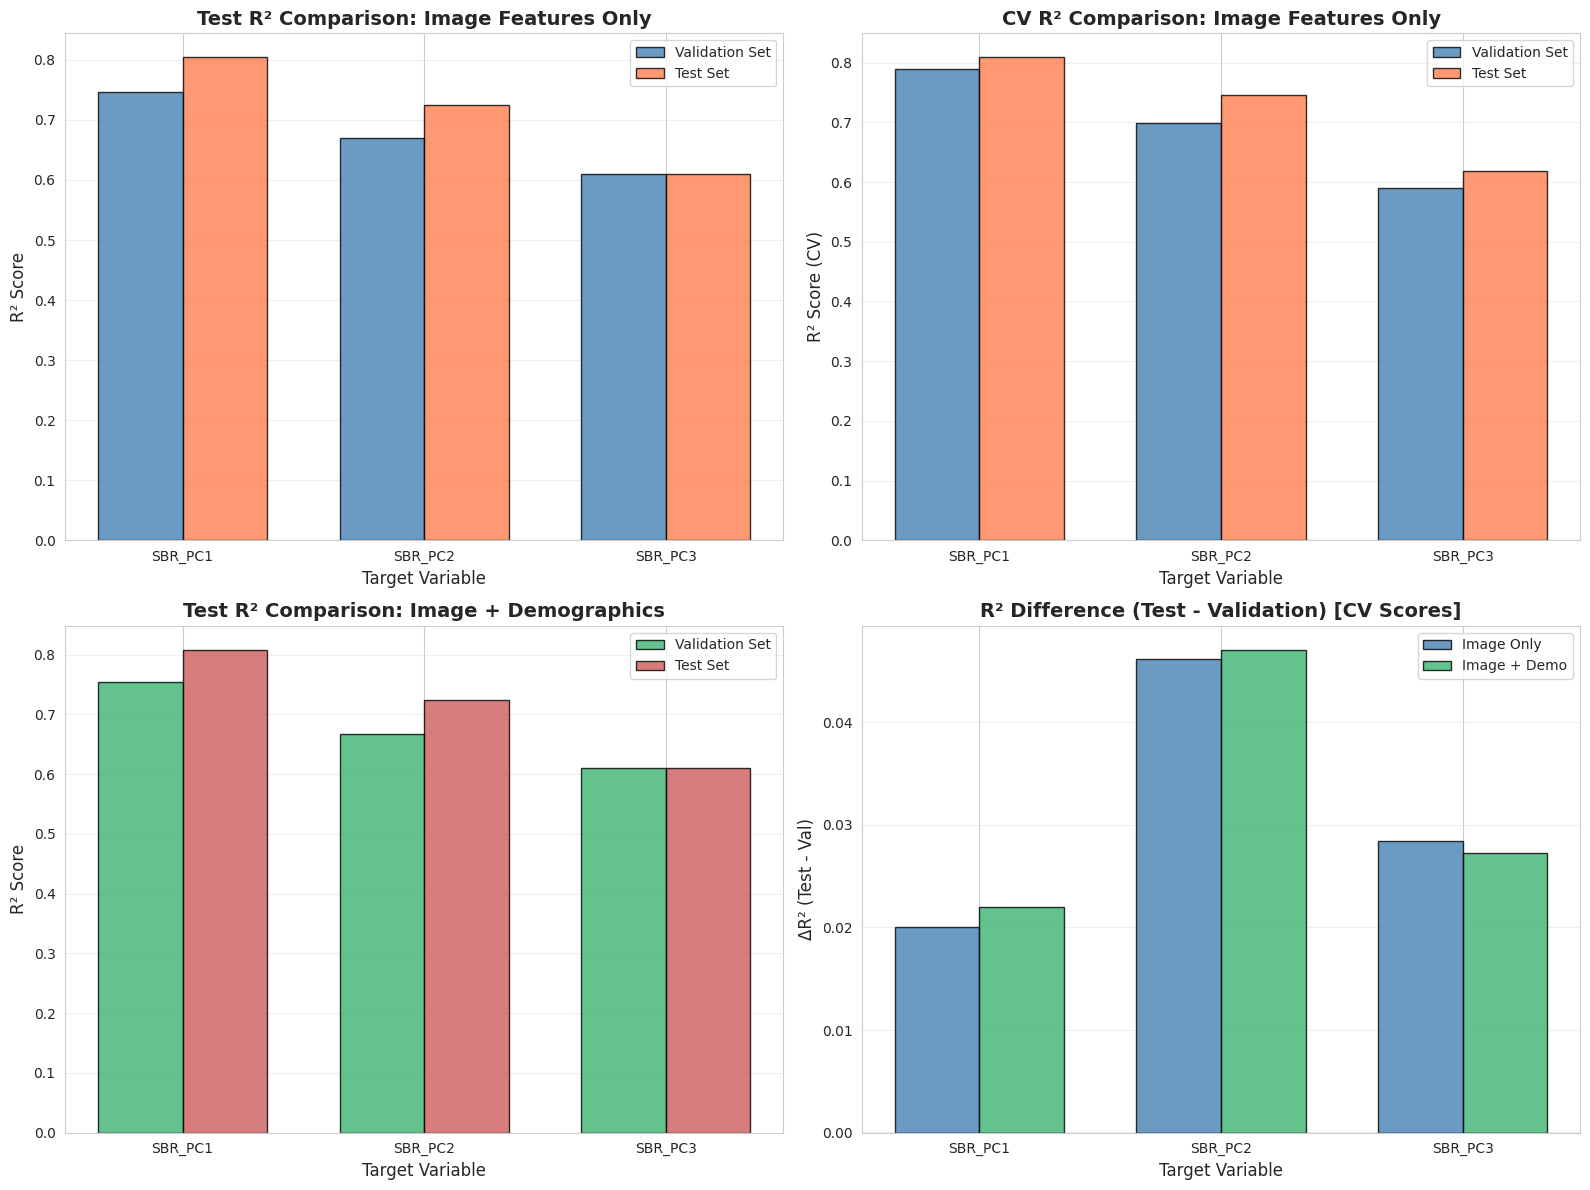


Plot saved to: output/validation_vs_test_comparison.png


In [15]:
if df_results_val is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Test R² Comparison (Image Only)
    img_only = df_comparison[df_comparison['Model']=='Image Features Only']
    x = np.arange(len(TARGETS))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, img_only['Val_Test_R2'], width, label='Validation Set', color='steelblue', alpha=0.8, edgecolor='black')
    axes[0, 0].bar(x + width/2, img_only['Test_Test_R2'], width, label='Test Set', color='coral', alpha=0.8, edgecolor='black')
    axes[0, 0].set_title('Test R² Comparison: Image Features Only', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Target Variable', fontsize=12)
    axes[0, 0].set_ylabel('R² Score', fontsize=12)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(TARGETS)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: CV R² Comparison (Image Only)
    axes[0, 1].bar(x - width/2, img_only['Val_CV_R2'], width, label='Validation Set', color='steelblue', alpha=0.8, edgecolor='black')
    axes[0, 1].bar(x + width/2, img_only['Test_CV_R2'], width, label='Test Set', color='coral', alpha=0.8, edgecolor='black')
    axes[0, 1].set_title('CV R² Comparison: Image Features Only', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Target Variable', fontsize=12)
    axes[0, 1].set_ylabel('R² Score (CV)', fontsize=12)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(TARGETS)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Test R² Comparison (Image + Demo)
    img_demo = df_comparison[df_comparison['Model']=='Image Features + Demographics']
    
    axes[1, 0].bar(x - width/2, img_demo['Val_Test_R2'], width, label='Validation Set', color='mediumseagreen', alpha=0.8, edgecolor='black')
    axes[1, 0].bar(x + width/2, img_demo['Test_Test_R2'], width, label='Test Set', color='indianred', alpha=0.8, edgecolor='black')
    axes[1, 0].set_title('Test R² Comparison: Image + Demographics', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Target Variable', fontsize=12)
    axes[1, 0].set_ylabel('R² Score', fontsize=12)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(TARGETS)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Difference in R² (Test - Validation)
    axes[1, 1].bar(x - width/2, img_only['Diff_CV_R2'], width, label='Image Only', color='steelblue', alpha=0.8, edgecolor='black')
    axes[1, 1].bar(x + width/2, img_demo['Diff_CV_R2'], width, label='Image + Demo', color='mediumseagreen', alpha=0.8, edgecolor='black')
    axes[1, 1].set_title('R² Difference (Test - Validation) [CV Scores]', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Target Variable', fontsize=12)
    axes[1, 1].set_ylabel('ΔR² (Test - Val)', fontsize=12)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(TARGETS)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    
    plt.tight_layout()
    plt.savefig('output/validation_vs_test_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nPlot saved to: output/validation_vs_test_comparison.png")

### 3.5 Save Results

In [16]:
# Save test set results
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

df_results_test.to_csv(output_dir / 'test_set_results.csv', index=False)
df_pivot_r2_test.to_csv(output_dir / 'test_set_r2_scores_test.csv')
df_pivot_r2_cv.to_csv(output_dir / 'test_set_r2_scores_cv.csv')
df_pivot_mse.to_csv(output_dir / 'test_set_mse_scores.csv')

if df_results_val is not None:
    df_comparison.to_csv(output_dir / 'validation_vs_test_comparison.csv', index=False)
    print(f"Comparison results saved to: {output_dir / 'validation_vs_test_comparison.csv'}")

print("\nTest set results saved to:")
print(f"  - {output_dir / 'test_set_results.csv'}")
print(f"  - {output_dir / 'test_set_r2_scores_test.csv'}")
print(f"  - {output_dir / 'test_set_r2_scores_cv.csv'}")
print(f"  - {output_dir / 'test_set_mse_scores.csv'}")

Comparison results saved to: output/validation_vs_test_comparison.csv

Test set results saved to:
  - output/test_set_results.csv
  - output/test_set_r2_scores_test.csv
  - output/test_set_r2_scores_cv.csv
  - output/test_set_mse_scores.csv
